# Introduction to MICrONS Data Access

[![](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AllenInstitute/connectomics_at_cosyne/blob/main/examples/Cosyne_Data_Access.ipynb)


<b> Electron Microscopy (EM) data enables morphological reconstruction of neurons and detection of their synaptic connectivity </b>. The <a href=https://www.microns-explorer.org/cortical-mm3>MICrONS dataset </a> is one of the largest datasets volume EM datasets currently available, and spans all layers of visual cortex. We will be using this dataset to query the connectivity between neurons in the visual cortex. 
    
<em> Note on data access: </em> To make our lifes easier, we already queried the most of the data needed for this exercise from the database. We have made it available as versioned files that can be read with pandas. The entire dataset is hosted using the <a href=https://caveconnectome.github.io/sections/cave_overview.html> Connectome Annotation Versioning Engine (CAVE) </a>. A separate notebook shows how to use CAVE to generate the files used in this notebook. 

In [28]:
from os.path import join as pjoin
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [29]:
materialization_version = 1718 # Current public as of March 2026
data_url = "https://github.com/AllenInstitute/connectomics_at_cosyne/raw/refs/heads/main/docs/resources/data"

## Visualize axon-proofread cells in the dataset

About the cell info table. The CAVE view that incorporates this information into a single view is: `aibs_cell_info`.

In [30]:
# Load the curated cell types table
# cell_types_df = pd.read_csv(pjoin(data_url, f'v{materialization_version}_cell_info.csv'))

cell_types_df = pd.read_csv('../docs/resources/data/v1718_cell_info.csv')

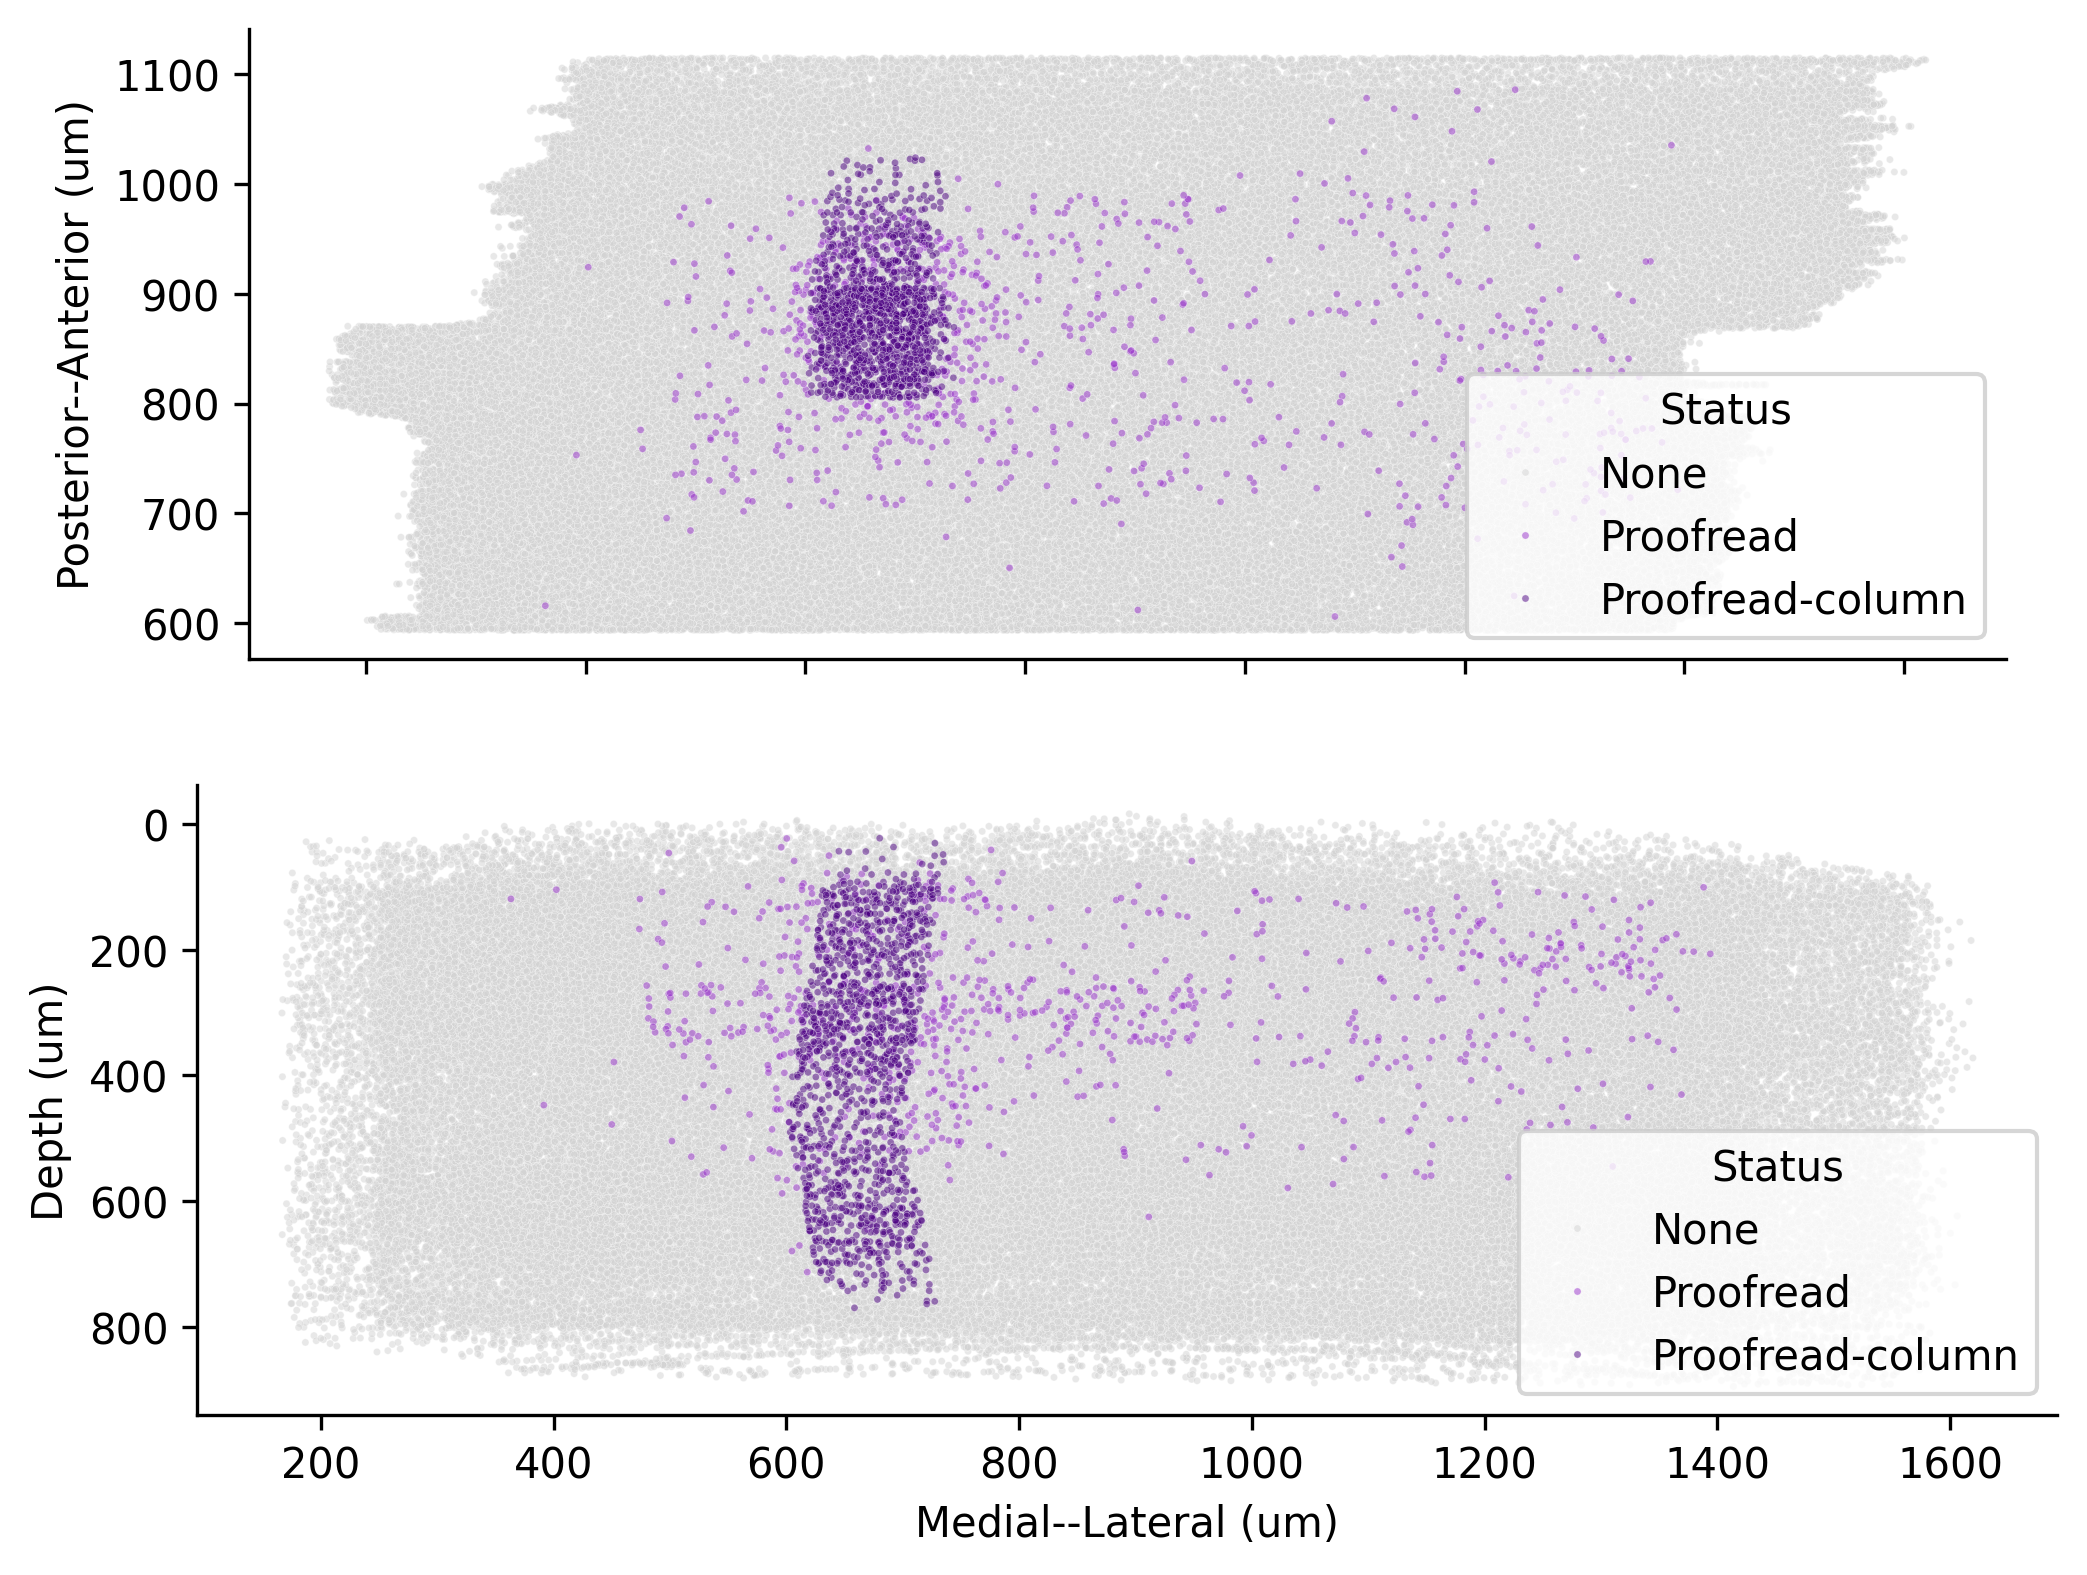

In [31]:
fig, ax = plt.subplots(2,1, figsize=(8, 6),dpi=300, sharex=True)

# Added a labeled column for ease of plotting
cell_types_df['Status'] = 'None'
cell_types_df.loc[cell_types_df.status_axon, 'Status'] = 'Proofread'
cell_types_df.loc[cell_types_df.is_column, 'Status'] = 'Proofread-column'
cell_types_df = cell_types_df.sort_values('Status')

# Plot xz-view (top down)
sns.scatterplot(cell_types_df,
                x='pt_position_x_tform',
                y='pt_position_z_tform',
                hue='Status',
                hue_order = ['None', 'Proofread', 'Proofread-column'], 
                palette={'Proofread-column': 'indigo', 'Proofread': 'darkorchid', 'None': 'lightgrey'},
                s=3,
                alpha=0.5,
                ax=ax[0]
               )
# Plot xy-view (coronal)
sns.scatterplot(cell_types_df,
                x='pt_position_x_tform',
                y='pt_position_y_tform',
                hue='Status',
                hue_order = ['None', 'Proofread', 'Proofread-column'], 
                palette={'Proofread-column': 'indigo', 'Proofread': 'darkorchid', 'None': 'lightgrey'},
                s=3,
                alpha=0.5,
                ax=ax[1]
               )

sns.despine()
ax[1].invert_yaxis()
ax[0].set(xlabel='Medial--Lateral (um)', ylabel='Posterior--Anterior (um)')
ax[1].set(xlabel='Medial--Lateral (um)', ylabel='Depth (um)')
ax[0].set_aspect("equal")

### Transformed coordinate system

## Synapse information

There are <b>337 million synapses</b> in the MICrONS dataset.

We have collected all of the input and output synapses for the proofread cells in version 1300. If you are interested in working with this dataset in the future, we added a notebook that shows how the data was queried.

Note that synapse queries always return the list of every synapse between the neurons in the query, even if there are multiple synapses between the same pair of neurons. A common pattern to generate a list of connections between unique pairs of neurons is to group by the root ids of the presynaptic and postsynaptic neurons and then count the number of synapses between them. 

<b> Here we will load all Proofread-to-Proofread connections within the column, </b> a small subset of the dataset. 

In [32]:
column_synapses = pd.read_feather(pjoin(data_url, f'v{materialization_version}_v1_column_synapses.feather'))
column_synapses.shape

(146711, 6)

### Connectivity matrix

The synapses of neurons create a network of connections. One way of visualizing this connectivity is in a matrix. Pandas provides the `pivot_table` function that we can use to make a matrix out of the tabular synapse data. For now, we will limit ourselves to the synapses between the proofread-column neurons.
    

<i>Note:</i> Each synapses has a `size` value assigned to it. How to aggregate the sizes from multiple synapes between two neurons depends on the research question. For now we ignore both synapse `size` and synapse `count`, and treat connection strength as <b>binary: connected or not-connected</b>

In [34]:
# matrix of synapse counts
syn_mat_binary = column_synapses.pivot_table(index="pre_pt_root_id", columns="post_pt_root_id", 
                                            values="size", aggfunc=lambda x: (np.sum(x) > 0)).fillna(0)

# Make sure matrix is quadratic
syn_mat_binary = syn_mat_binary.reindex(columns=np.array(syn_mat_binary.index)).astype(float)

row_indices, column_indices = np.nonzero(syn_mat_binary)

NameError: name 'syn_mat' is not defined

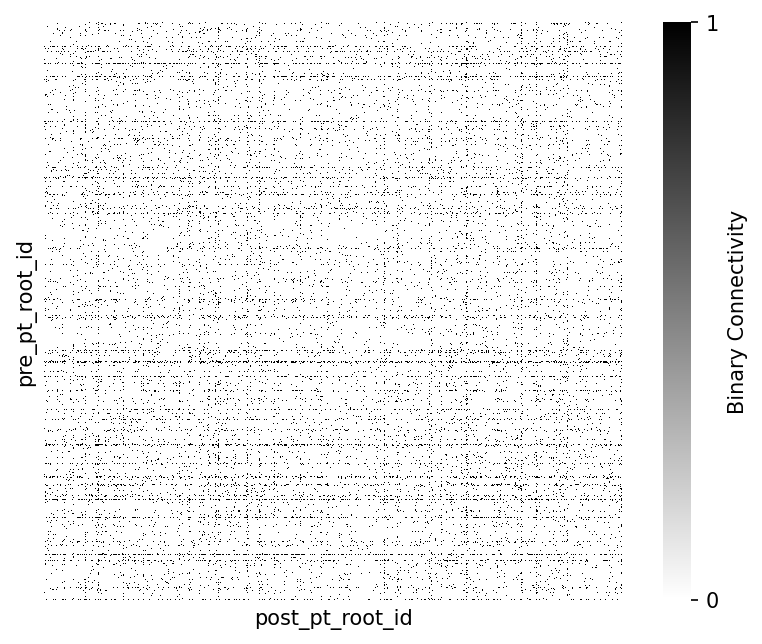

In [35]:
fig, ax = plt.subplots(figsize=(7, 5), dpi=150)
sns.heatmap(syn_mat_binary, cmap="gray_r", xticklabels=[], yticklabels=[], 
            ax=ax, square=True,
            cbar_kws={"label": "Binary Connectivity", "ticks": [0, 1]})


n_edges = len(row_indices)
n_possible_edges = syn_mat.shape[0] * syn_mat.shape[1]
print(f"Number of edges: {n_edges}")
print(f"Number of possible edges: {n_possible_edges}")
print(f"Fraction of possible edges: {n_edges / n_possible_edges:.4f}")

<h4> Consider: different measures of synaptic strength </h4>

When creating a connectivity matrix, how you measure synaptic strength can make a difference in your analysis. For 3 common ways of reporting connection strength:

<ol>
    <li> <b> Binary connectivity:</b> whether two cells are connected at all, as shown above.</li>
    <li> <b> Synaptic count:</b> the total number of synapses that are part of the connection. This is typical of the Fly connectome where <code>count</code> captures much of the connection diversity. The modal <code>count</code> in mouse cortex is much lower.</li>
    <li> <b> Synaptic size:</b> the size of the postsynaptic density at every connection, generally aggregated as <code>sum</code> or <code>mean</code> for each unique connection.</li>
    
</ol>

<p>How to take synapse size and number into account depends on the specific analysis. 


<i>Note:</i> The `size` reported in the MICrONS dataset measures the synaptic cleft as segmented by the automated classifier in voxels (3d pixels, a measure of volume). These are correlated to anatomical measures such as synaptic area and spine head volumes (for excitatory synapses). 

Let's consider synapse `count` first and seperately, using the same pivot table but with `aggfunc=lambda x: np.sum(x > 0)`:

### Synapse count

[Text(0.5, 0, 'Number of synapses per connection'),
 Text(0, 0.5, 'Number of connections')]

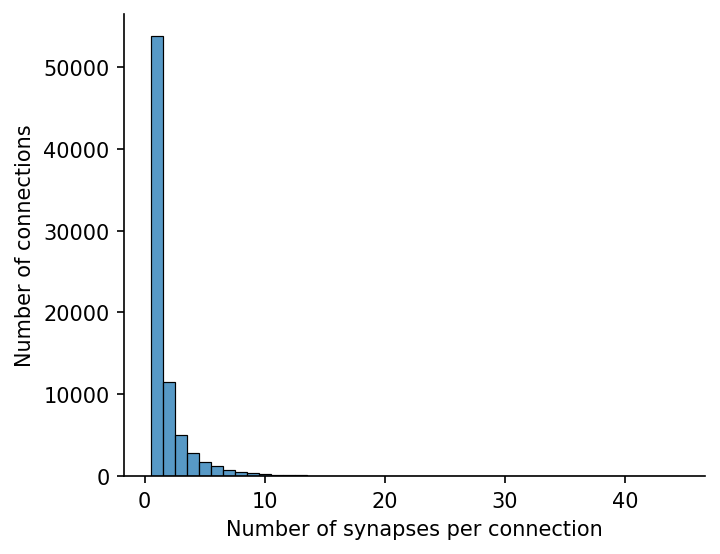

In [36]:
# Count Histogram on linear-x
syn_mat = column_synapses.pivot_table(index="pre_pt_root_id", columns="post_pt_root_id", 
                                            values="size", aggfunc=lambda x: np.sum(x > 0)).fillna(0)

# Make sure matrix is quadratic
syn_mat = syn_mat.reindex(columns=np.array(syn_mat.index)).astype(float)

fig, ax = plt.subplots(figsize=(5, 4), dpi=150)
edge_weights = syn_mat.to_numpy()[row_indices, column_indices]
sns.histplot(
    edge_weights,
    discrete=True,
    ax=ax,
)
ax.spines[["top", "right"]].set_visible(False)
ax.set(xlabel="Number of synapses per connection", ylabel="Number of connections")

In other systems than mouse cortex, the number of synapses might be the more important measure (see [Dorkenwald et al., 2022](https://elifesciences.org/articles/76120) for deeper dive into synapse size and counts). 

However, in mouse cortex the modal number of <b>Excitatory-to-excitatory connections is 1</b>, while inhibitory-excitatory connections may be more varied


In [37]:
# extract only the synapses between excitatory-excitatory cells in the column
excitatory_root_ids = cell_types_df.query("broad_type=='excitatory'").pt_root_id.to_numpy()

# Filter synapse table for excitatory-excitatory connections
exc_exc_synapses = column_synapses.loc[(column_synapses.pre_pt_root_id.isin(excitatory_root_ids) &
                                        column_synapses.post_pt_root_id.isin(excitatory_root_ids)
                                                 )]

np.shape(exc_exc_synapses)

(36233, 6)

In [38]:
# Filter synapse table for inhibitory-excitatory connections
inhibitory_root_ids = cell_types_df.query("broad_type=='inhibitory'").pt_root_id.to_numpy()
inh_exc_synapses = column_synapses.loc[(column_synapses.pre_pt_root_id.isin(inhibitory_root_ids) &
                                        column_synapses.post_pt_root_id.isin(excitatory_root_ids)
                                                 )]
np.shape(inh_exc_synapses)

(72765, 6)

[Text(0.5, 1.0, 'Inhibitory-Excitatory'), Text(0, 0.5, '')]

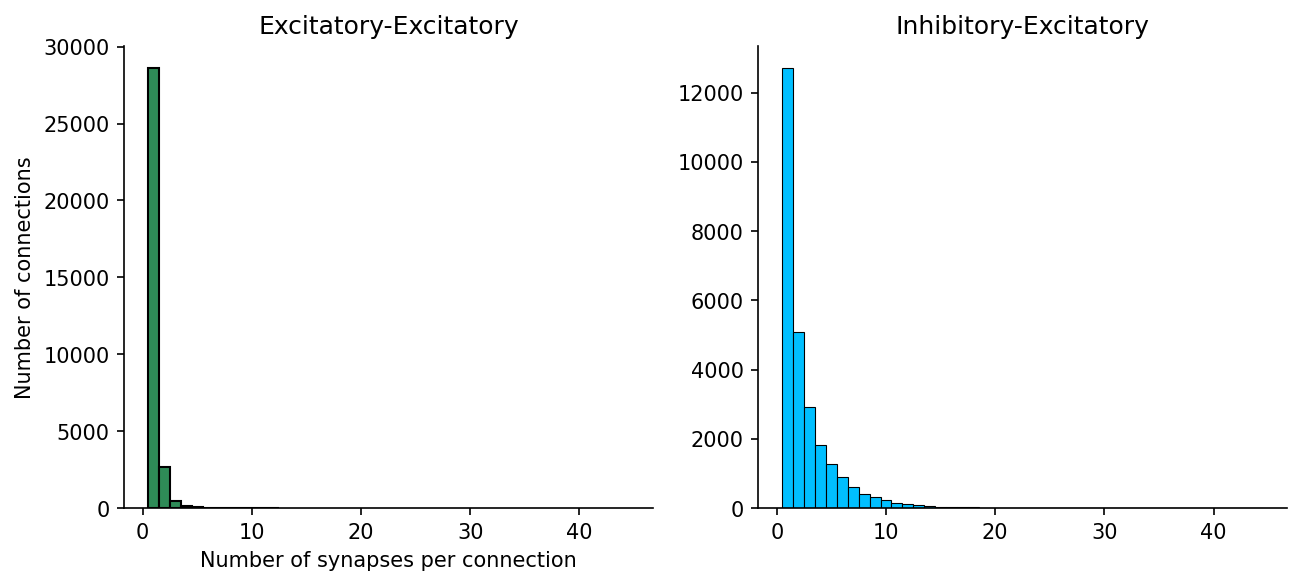

In [55]:
fig, ax = plt.subplots(1,2, figsize=(10, 4),dpi=150, sharex=True)

syn_mat = exc_exc_synapses.pivot_table(index="pre_pt_root_id", columns="post_pt_root_id", 
                                       values="size", aggfunc=lambda x: np.sum(x > 0)).fillna(0)
# Make sure matrix is quadratic
syn_mat = syn_mat.reindex(columns=np.array(syn_mat.index)).astype(float)
row_indices, column_indices = np.nonzero(syn_mat)
edge_weights = syn_mat.to_numpy()[row_indices, column_indices]

sns.histplot(
    edge_weights,
    discrete=True,
    ax=ax[0],
    facecolor='seagreen',
)


syn_mat = inh_exc_synapses.pivot_table(index="pre_pt_root_id", columns="post_pt_root_id", 
                                       values="size", aggfunc=lambda x: np.sum(x > 0)).fillna(0)
## This matrix cannot be quadratic
# syn_mat = syn_mat.reindex(columns=np.array(syn_mat.index)).astype(float)
row_indices, column_indices = np.nonzero(syn_mat)
edge_weights = syn_mat.to_numpy()[row_indices, column_indices]

sns.histplot(
    edge_weights,
    discrete=True,
    ax=ax[1],
    facecolor='deepskyblue',
)

sns.despine()
ax[0].set(title='Excitatory-Excitatory', xlabel="Number of synapses per connection", ylabel="Number of connections")
ax[1].set(title='Inhibitory-Excitatory', ylabel=None)

### Synapse Size

In mouse visual cortex, the diversity in <b>Excitatory to excitatory</b> connectivity is much more often in synaptic `size`:

C:\Users\bethanny.danskin\Documents\GitHub\connectomics_at_cosyne\.venv\Lib\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


[Text(0.5, 0, 'Sum synapse size (voxels - log scale)'),
 Text(0, 0.5, 'Number of connections')]

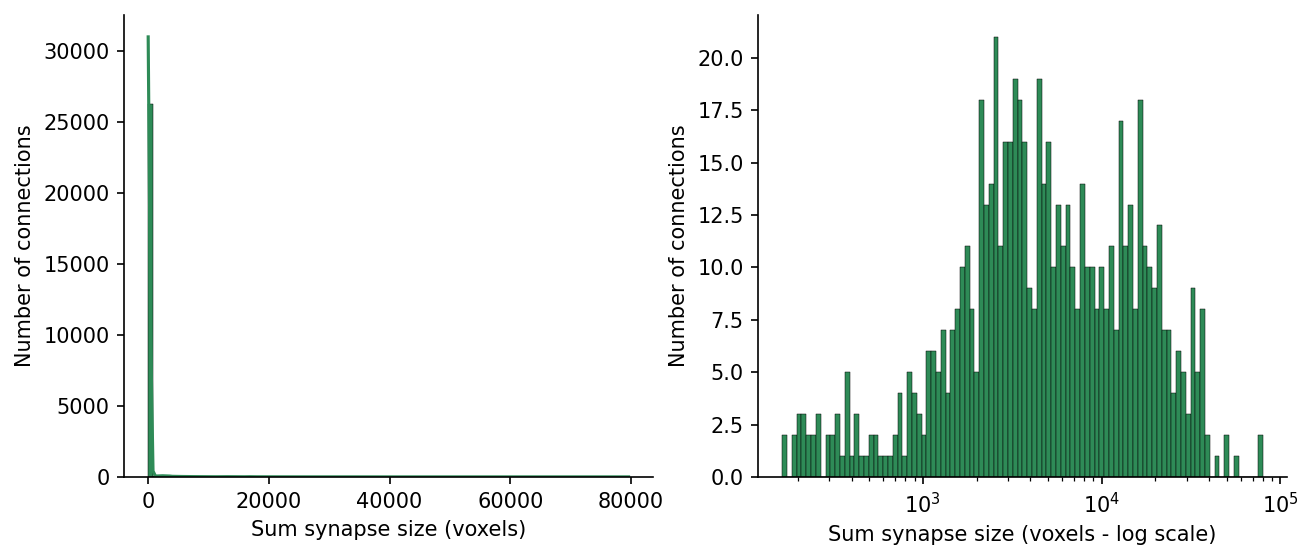

In [57]:
fig, axs = plt.subplots(1, 2, figsize=(10, 4), dpi=150)

syn_mat = exc_exc_synapses.pivot_table(index="pre_pt_root_id", columns="post_pt_root_id", 
                                            values="size", aggfunc=lambda x: (np.sum(x))).fillna(0)

# Make sure matrix is quadratic
syn_mat = syn_mat.reindex(columns=np.array(syn_mat.index)).astype(float)

# collect the synaptic weights that are non-zero
edge_weights = syn_mat.to_numpy()[row_indices, column_indices]

# Histogram on linear-x
ax = axs[0]
sns.histplot(
    edge_weights,
    kde=True,
    bins=100,
    ax=ax,
    log_scale=False,
    facecolor='seagreen',
)
ax.spines[["top", "right"]].set_visible(False)
ax.set(xlabel="Sum synapse size (voxels)", ylabel="Number of connections")

# Histogram on log-x
ax = axs[1]
sns.histplot(
    edge_weights,
    kde=True,
    bins=100,
    ax=ax,
    log_scale=True,
    facecolor='seagreen',
)
ax.spines[["top", "right"]].set_visible(False)
ax.set(xlabel="Sum synapse size (voxels - log scale)", ylabel="Number of connections")


Let's replot the <b>square matrix</b> with the log of the <code>sum</code> of synapses sizes between each connected pair `aggfunc=lambda x: np.log(np.sum(x))`

In [58]:
# matrix of log-summed synapse size
syn_mat_logsum = column_synapses.pivot_table(index="pre_pt_root_id", columns="post_pt_root_id", 
                                            values="size", aggfunc=lambda x: np.log(np.sum(x))).fillna(0)

# Make sure matrix is quadratic
syn_mat_logsum = syn_mat_logsum.reindex(columns=np.array(syn_mat.index)).astype(float)

row_indices, column_indices = np.nonzero(syn_mat_logsum)

Number of edges: 58840
Number of possible edges: 1413721
Fraction of possible edges: 0.0416


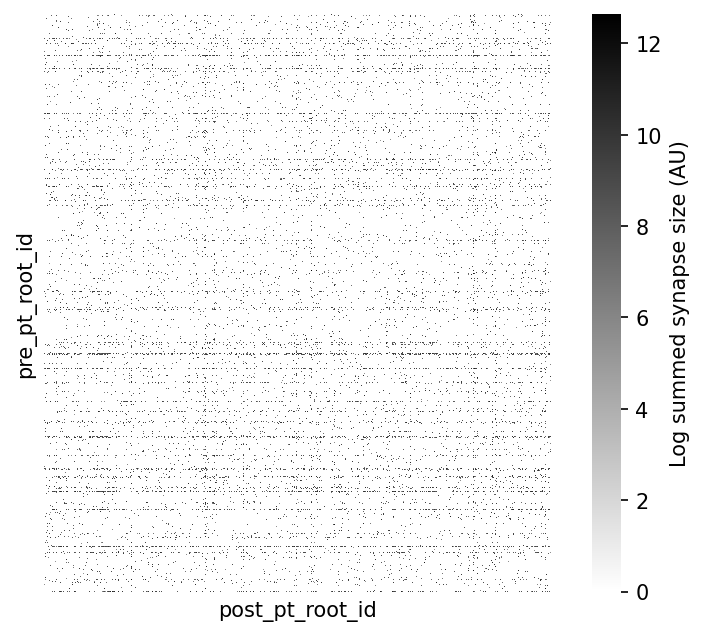

In [59]:
fig, ax = plt.subplots(figsize=(7, 5), dpi=150)
sns.heatmap(syn_mat_logsum, cmap="gray_r", xticklabels=[], yticklabels=[], 
            ax=ax, square=True,
            cbar_kws={"label": "Log summed synapse size (AU)"})


n_edges = len(row_indices)
n_possible_edges = syn_mat.shape[0] * syn_mat.shape[1]
print(f"Number of edges: {n_edges}")
print(f"Number of possible edges: {n_possible_edges}")
print(f"Fraction of possible edges: {n_edges / n_possible_edges:.4f}")

## Cell type tables

Identifying the putative ‘cell type’ from the EM morphology is a process that involves both manual and automatic classifications. Subsets of the dataset have been manually classified by anatomists at the Allen Institute, and these ground truth labels used to train and refine different automated ‘feature classifiers’ over time. 

### Using the automated cell types

Many of these automated cell type definitions were established and refined for the [MICrONS Dataset](https://www.microns-explorer.org/) including: 

<ul>
    <li> Perisomatic cell features <a href=https://www.nature.com/articles/s41586-024-07765-7>(Elabbady et al.)</a> </li>
    <li> Morphology and connectivity features <a href=https://www.nature.com/articles/s41586-024-07780-8>(Schneider-Mizell et al.)</a> </li>
    <li> Dendrite and spine multifeature model. The process of applying these labels is ongoing. </a> </li>
</ul>

Casey Schneider-Mizell's most recent cell typing, the multifeature cell typing, is available in CAVE from the <code>cell_type_multifeature_combo</code> table which labels cell types according to using soma, nucleus, dendrite, and spine features. These are colated in the `meso_type` column of our cell types dataframe. 

<b>For this demonstation, we will use `cell_types` from the perisomatic cell features</b>. Choose an alternate cell type classification at your discretion. 

*Note:* Cells here without a label are NaN. These are either non-neuronal cells or potential neurons with large segmentation errors that did not pass quality check

In [60]:
cell_types_df.value_counts(['cell_type']).sort_index()

cell_type
23P          19650
4P           14712
5P-ET         2149
5P-IT         7890
5P-NP          932
6P-CT         6770
6P-IT        11651
BC            3354
BPC           1494
MC            2469
NGC            588
OPC           1422
astrocyte     6898
microglia     2358
oligo         6901
pericyte       374
Name: count, dtype: int64

### Sorting the synapse matrix with cell types
    
Let's combine the synaptic connecitivity with the cell type information. Below we provide logic for sorting a connectivity matrix using a list of labels.  

In [61]:
def sort_matrix_by_types(mat: pd.DataFrame, 
                         labels: pd.DataFrame, 
                         label_type_col: str = "cell_type_auto", 
                         label_id_col: str = "pt_root_id", 
                         post_labels: pd.DataFrame = None, 
                         post_label_type_col: str = None, 
                         post_label_id_col: str = None):
    """Sorts (synapse) matrix by labels.

    This function assumes a square synapse matrix!

    Args:
        mat: synapse matrix as pandas DataFrame
        labels: DataFrame with labels, e.g. the output of client.materialize.query_table('aibs_metamodel_celltypes_v661')
        label_type_col: column name in labels for cell types
        label_id_col: column name in labels for root ids
        post_labels: DataFrame with labels, e.g. the output of client.materialize.query_table('aibs_metamodel_celltypes_v661')
        post_label_type_col: column name in labels for cell types
        post_label_id_col: column name in labels for root ids

    Returns:
        mat_sorted: sorted matrix
        mat_labels: sorted labels; has the same length as matrix
    """
    
    if post_labels is None:
        post_labels = labels
    if post_label_type_col is None:
        post_label_type_col = label_type_col
    if post_label_id_col is None:
        post_label_id_col = label_id_col
        
    mat_sorted = mat.copy()
    
    pre_mat_labels = np.array(labels.set_index(label_id_col).loc[mat_sorted.index][label_type_col])
    pre_sorting = np.argsort(pre_mat_labels)

    post_mat_labels = np.array(post_labels.set_index(post_label_id_col).loc[mat_sorted.T.index][post_label_type_col])
    post_sorting = np.argsort(post_mat_labels)

    mat_sorted = mat_sorted.iloc[pre_sorting].T.iloc[post_sorting].T

    return mat_sorted, pre_mat_labels[pre_sorting], post_mat_labels[post_sorting]

In [63]:
# Sort the column connectivity
syn_mat = column_synapses.pivot_table(index="pre_pt_root_id", columns="post_pt_root_id", 
                                            values="size", aggfunc=lambda x: np.log(np.sum(x))).fillna(0)

syn_mat = syn_mat.reindex(columns=np.array(syn_mat.index)).astype(float)

# sort the matrix by cell types to render sensibly in heatmap
cell_types_df = cell_types_df.fillna({'cell_type': 'unknown', 'broad_type': 'unknown', 'meso_type': 'unknown'})
syn_mat_ct, syn_mat_cell_types, _ = sort_matrix_by_types(syn_mat, cell_types_df, label_type_col="cell_type")

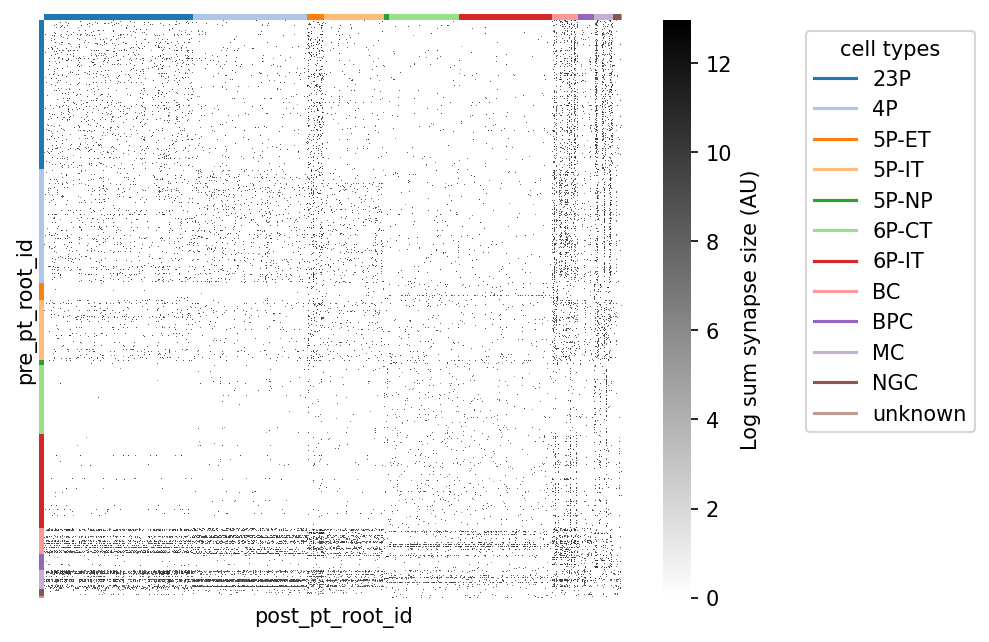

In [64]:
import matplotlib
# add colormap for cell type
cts, ct_idx = np.unique(syn_mat_cell_types, return_inverse=True)
ct_colors = plt.get_cmap("tab20")(ct_idx)

fig, ax = plt.subplots(figsize=(7, 5), dpi=150)
sns.heatmap(syn_mat_ct, cmap="gray_r", xticklabels=[], yticklabels=[], 
            ax=ax, square=True,
            cbar_kws={"label": "Log sum synapse size (AU)"})


# Adding row and column colors for cell types
for i, color in enumerate(ct_colors):
    ax.add_patch(plt.Rectangle(xy=(-0.01, i), width=0.01, height=1, color=color, lw=0,
                               transform=ax.get_yaxis_transform(), clip_on=False))

for i, color in enumerate(ct_colors):
    ax.add_patch(plt.Rectangle(xy=(i, 1), height=0.01, width=1, color=color, lw=0,
                               transform=ax.get_xaxis_transform(), clip_on=False))

# add a legend for the cell types
legend_elements = [matplotlib.lines.Line2D([0], [0], color=plt.get_cmap("tab20")(i), label=ct) for i, ct in enumerate(cts)]
plt.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(1.3, 1), title="cell types")
plt.show()

## Beyond proofread-to-proofread connectivity

In the MICrONS dataset, the general rule is that dendrites onto cells with a cell body are sufficiently proofread to trust synaptic connections onto a cell. Axons on the other hand require so much proofreading that only ~2250 cells have proofread axons.

Proofreading status is available from CAVE table `proofreading_status_and_strategy`, and from the previously loaded cell types table.

In [65]:
cell_types_df.value_counts(['status_axon','strategy_axon'])

status_axon  strategy_axon          
False        none                       119826
True         axon_partially_extended      1576
             axon_fully_extended           518
             axon_interareal               120
Name: count, dtype: int64

Axon and dendrite compartment status are marked separately, as proofreading effort was applied differently to the different compartments in some cells.  In all cases, a status of `TRUE` indicates that false merges have been comprehensively removed, and the compartment is at least ‘clean’. Consult the ‘strategy’ column if completeness of the compartment is relevant to your  research.

Some cells were extended to different degrees of completeness, or with different research goals in mind. This is denoted by 'strategy_axon', which may be one of:

<ul>
    <li>none: No cleaning, and no extension, and status is `FALSE`. </li>
    <li>axon_partially_extended: The axon was extended outward from the soma, following each branch to its termination. Output synapses represent a sampling of potential partners. </li>
    <li>axon_interareal: The axon was extended with a preference for branches that projected to other brain areas. Some axon branches were fully extended, but local connections may be incomplete. Output synapses represent a sampling of potential partners. </li>
    <li>axon_fully_extended: Axon was extended outward from the soma, following each branch to its termination. After initial extension, every endpoint was identified, manually inspected, and extended again if possible. Output synapses represent a largely complete sampling of partners.. </li>
</ul>

In [66]:
proofread_cells = cell_types_df.query('status_axon==True').pt_root_id.to_numpy()
print(f'Cells with proofread axons: {len(proofread_cells)}')

Cells with proofread axons: 2214


Previously we worked with the proofread cells among the V1 column, which totaled `146,711` unique synapses. However, the total number of <b>outputs from all proofread cells to any cell </b> is much higher: `2,493,674`. And 


In [85]:
all_output_synapses = pd.read_feather(pjoin(data_url, f'v{materialization_version}_proofread_output_synapses.feather'))
print(f'All outputs from proofread neurons : {len(all_output_synapses)}')

neuron_ids = cell_types_df.query("(broad_type=='excitatory') | (broad_type=='inhibitory')").pt_root_id.to_numpy()
known_output_synapses = all_output_synapses.loc[all_output_synapses.post_pt_root_id.isin(neuron_ids)]
print(f'Synapses between known neurons (from proofread to any neuron): {len(known_output_synapses)}')

connection_counts = known_output_synapses.value_counts(['pre_pt_root_id','post_pt_root_id'])
print(f'Unique (binarized) connections between known neurons (from proofread to any neuron): {len(connection_counts)}')

All outputs from proofread neurons : 2493674
Synapses between known neurons (from proofread to any neuron): 2088830
Unique (binarized) connections between known neurons (from proofread to any neuron): 1257392


In [87]:
%%time
# Binarized connectivity for all synapses
rect_syn_mat = known_output_synapses.pivot_table(index="pre_pt_root_id", columns="post_pt_root_id", 
                                            values="size", aggfunc=lambda x: (np.sum(x)>0)).fillna(0)
np.shape(rect_syn_mat)

CPU times: total: 55.8 s
Wall time: 1min 18s


(2275, 63718)

<img src="https://raw.githubusercontent.com/AllenInstitute/connectomics_at_cosyne/refs/heads/main/docs/resources/column_only_synapses.png" alt="synapses in column" align="left" style="width:500px;margin-right:10px;">
<img src="https://raw.githubusercontent.com/AllenInstitute/connectomics_at_cosyne/refs/heads/main/docs/resources/column_and_all_synapses.png" alt="all synapses" align="left" style="width:500px;">
<p style="clear:both;">

Dig deeper, additional context
1. CAVE access (microns, v1dd, flywire, fafb, h01, etc)
2. ossify for skeleton download
3. plot outputs from a proofread cell
4. plot inputs to proofread cell
5. filter by connections to known neurons; asymmetry of the data
6. post synaptic struture: onto spine, shaft, soma
7. inference of connectivity by cell type (cite ben's paper)
8. branch topology of synapses, colored by distance to soma

Beyond connectivity
1. non neuronal cells
2. interactions at synapses
3. organelle segmentation

# CAVE account setup 

<p>In order to manage server traffic, every user needs to create a CAVE account and download a user token to access CAVE's services programmatically. The CAVE infrastructure can be read about in <a href='https://www.nature.com/articles/s41592-024-02426-z'>more detail in the CAVE Paper</a>. 
    
<p>The MICrONS data is publicly available which means that no extra permissions need to be given to a new user account to access the data. Bulk downloads of some static data are also available without an account on <a href='https://microns-explorer.org/'> MICrONs Explorer</a>.

<b> A Google account (or Google-enabled account) is required to create a CAVE account.

<p> Go to: <a href=https://global.daf-apis.com/auth/api/v1/user/token> https://global.daf-apis.com/auth/api/v1/user/token </a>to view a list of your existing tokens
<p> If you have never made a token before: 
<ol>
  <li>go here: <a href=https://global.daf-apis.com/sticky_auth/api/v1/tos/2/accept>https://global.daf-apis.com/sticky_auth/api/v1/tos/2/accept</a> to accept terms of service</li>
  <li>then go here <a href=https://global.daf-apis.com/auth/api/v1/create_token> https://global.daf-apis.com/auth/api/v1/create_token</a> to create a new token.</li>
</ol>

In [ ]:
%%capture
!uv pip install caveclient
!uv pip install ossify

In [ ]:
import caveclient

my_token = "PASTE_TOKEN_HERE"
client = caveclient.CAVEclient("minnie65_public", auth_token=my_token)

### Setup a persisent token for CAVE authentication
   
<p>If you are running this on your local machine rather than colab, you may also store the token on your machine. This makes future access easier as you do not have to specify the token.

```
client.auth.save_token(token=my_token, overwrite=True)
```